using: /kaggle/working/ml-100k/u.data
ratings: 100000 | users: 943 | items: 1682 | density: 0.0630
rating distribution (share): {1: 0.061, 2: 0.114, 3: 0.271, 4: 0.342, 5: 0.212}
ratings per user min/median/max: 20 65 737 | per item: 1 27 583
items with fewer than 5 ratings: 19.8% | duplicate (user, item) pairs: 0


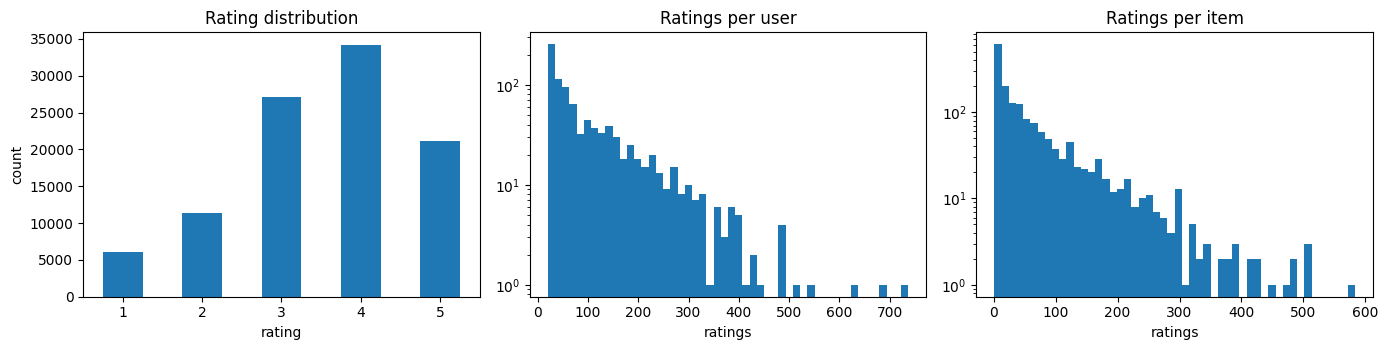

In [1]:
import numpy as np, pandas as pd, os, time, glob, random, zipfile, urllib.request
import matplotlib.pyplot as plt

WORK = "/kaggle/working" if os.path.exists("/kaggle/working") else ("/content" if os.path.exists("/content") else ".")
os.makedirs(f"{WORK}/results", exist_ok=True)
try:
    urllib.request.urlretrieve("https://files.grouplens.org/datasets/movielens/ml-100k.zip", f"{WORK}/ml-100k.zip")
    zipfile.ZipFile(f"{WORK}/ml-100k.zip").extractall(WORK)
    UDATA = f"{WORK}/ml-100k/u.data"
except Exception as e:
    print("download failed:", e)
    found = glob.glob("/kaggle/input/**/u.data", recursive=True)
    print("u.data found in attached inputs:", found)
    UDATA = found[0]
print("using:", UDATA)

df = pd.read_csv(UDATA, sep="\t", names=["user", "item", "rating", "ts"])
assert df.shape[1] == 4 and df.rating.between(1, 5).all(), "unexpected file format"
n_users, n_items, n_r = df.user.nunique(), df.item.nunique(), len(df)
print("ratings:", n_r, "| users:", n_users, "| items:", n_items, "| density: %.4f" % (n_r / (n_users * n_items)))
print("rating distribution (share):", df.rating.value_counts(normalize=True).sort_index().round(3).to_dict())
pu, pi_ = df.groupby("user").size(), df.groupby("item").size()
print("ratings per user min/median/max:", pu.min(), int(pu.median()), pu.max(), "| per item:", pi_.min(), int(pi_.median()), pi_.max())
print("items with fewer than 5 ratings: %.1f%%" % (100 * (pi_ < 5).mean()), "| duplicate (user, item) pairs:", int(df.duplicated(["user", "item"]).sum()))
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
df.rating.value_counts().sort_index().plot.bar(ax=ax[0], rot=0); ax[0].set_title("Rating distribution"); ax[0].set_xlabel("rating"); ax[0].set_ylabel("count")
ax[1].hist(pu, bins=50); ax[1].set_yscale("log"); ax[1].set_title("Ratings per user"); ax[1].set_xlabel("ratings")
ax[2].hist(pi_, bins=50); ax[2].set_yscale("log"); ax[2].set_title("Ratings per item"); ax[2].set_xlabel("ratings")
plt.tight_layout(); plt.savefig(f"{WORK}/results/cf_data_overview.png", dpi=150, bbox_inches="tight"); plt.show()

## Dataset: MovieLens 100K

MovieLens 100K (GroupLens; Harper and Konstan, "The MovieLens Datasets: History
and Context", ACM TiiS, 2015) holds 100,000 ratings from 1 to 5 by 943 users on
1,682 movies (density 6.3%, no duplicate pairs). Every user has at least 20
ratings (median 65, maximum 737); items have 1 to 583 (median 27), and 19.8%
of items have fewer than 5. Ratings skew positive (mean about 3.53; 4 is the
most common). Both counts are heavy-tailed (log-scale plots).

It suits both algorithms because it has **explicit ratings**, so neighbourhood
methods and matrix factorisation can both predict a rating and be scored with
RMSE and MAE (as in the README's worked example); the matrix is **sparse but
not empty**, which is where latent factors are meant to help and where
neighbourhood similarities become noisy; and it is **small enough** for dense
matrices and many experiments. Limits: ratings are explicit, not implicit
clicks (it says nothing about CTR); only users who chose to rate appear;
popularity is heavily skewed; and it is small by industrial standards.

In [2]:
SEED = 42
rng = np.random.default_rng(SEED); random.seed(SEED)
uid = {u: k for k, u in enumerate(sorted(df.user.unique()))}; iid = {i: k for k, i in enumerate(sorted(df.item.unique()))}
d = pd.DataFrame({"u": df.user.map(uid).to_numpy(), "i": df.item.map(iid).to_numpy(), "r": df.rating.to_numpy(np.float64)})
perm = rng.permutation(len(d)); n_tr, n_va = int(0.8 * len(d)), int(0.1 * len(d))
tr, va, te = d.iloc[perm[:n_tr]], d.iloc[perm[n_tr:n_tr + n_va]], d.iloc[perm[n_tr + n_va:]]
U, I = len(uid), len(iid)
R = np.zeros((U, I)); M = np.zeros((U, I), dtype=bool)
R[tr.u, tr.i] = tr.r; M[tr.u, tr.i] = True
print("train / val / test ratings:", len(tr), len(va), len(te))
print("fingerprint | train rating sum", int(tr.r.sum()), "| val rating sum", int(va.r.sum()), "| test rating sum", int(te.r.sum()))
print("cold start in val: users unseen in train", int((~va.u.isin(tr.u)).sum()), "| items unseen in train", int((~va.i.isin(tr.i)).sum()))

def rmse(y, p): return float(np.sqrt(np.mean((y - p) ** 2)))
def mae(y, p): return float(np.mean(np.abs(y - p)))
def clip(p): return np.clip(p, 1.0, 5.0)

mu = tr.r.mean()
n_i = M.sum(0); n_u = M.sum(1)
item_mean = np.where(n_i > 0, R.sum(0) / np.maximum(n_i, 1), mu)
user_mean = np.where(n_u > 0, R.sum(1) / np.maximum(n_u, 1), mu)
LAM = 10.0
bi = ((R - mu) * M).sum(0) / (n_i + LAM)
bu = (((R - mu - bi[None, :]) * M).sum(1)) / (n_u + LAM)
B = mu + bu[:, None] + bi[None, :]
base = {"global mean": np.full((U, I), mu), "item mean": np.tile(item_mean, (U, 1)),
        "user mean": np.tile(user_mean[:, None], (1, I)), "bias baseline (mu+bu+bi)": B}
yv = va.r.to_numpy(); rows = []
for name, Pm in base.items():
    p = clip(Pm[va.u, va.i]); rows.append((name, rmse(yv, p), mae(yv, p)))
print(pd.DataFrame(rows, columns=["baseline", "val RMSE", "val MAE"]).round(4).to_string(index=False))

train / val / test ratings: 80000 10000 10000
fingerprint | train rating sum 282317 | val rating sum 35240 | test rating sum 35429
cold start in val: users unseen in train 0 | items unseen in train 21
                baseline  val RMSE  val MAE
             global mean    1.1320   0.9485
               item mean    1.0295   0.8179
               user mean    1.0457   0.8386
bias baseline (mu+bu+bi)    0.9494   0.7517


## Split and baselines

A random 80/10/10 split of the ratings (seed 42): 80,000 train, 10,000
validation and 10,000 test ratings; every statistic is learned from the
training part only. Mean ratings are 3.529, 3.524 and 3.543. In validation,
no user and 21 items (0.2% of ratings) are unseen in training and fall back to
the baseline. Baselines: the bias baseline predicts the training mean plus a
user bias and an item bias, each shrunk toward zero (sum divided by count plus
10, a choice of mine, not tuned).

| Baseline | Val RMSE | Val MAE |
|---|---|---|
| Global mean | 1.1320 | 0.9485 |
| Item mean | 1.0295 | 0.8179 |
| User mean | 1.0457 | 0.8386 |
| Bias baseline | 0.9494 | 0.7517 |

The bias baseline is the reference that matters: it already captures that some
users rate high and some movies are better liked (16% below the global mean).

In [3]:
Rc = np.where(M, R - B, 0.0)                     # residuals of observed ratings over the bias baseline
Mf = M.astype(np.float64)

def sim_matrix(X, shrink):
    G = X @ X.T; nrm = np.sqrt(np.diag(G)); S = G / np.maximum(nrm[:, None] * nrm[None, :], 1e-12)
    if shrink > 0:
        n_common = (X != 0).astype(np.float64) @ (X != 0).astype(np.float64).T
        S = S * n_common / (n_common + shrink)
    np.fill_diagonal(S, 0.0); return S
def topk_rows(S, k):
    Sk = np.zeros_like(S); idx = np.argpartition(-np.abs(S), k, axis=1)[:, :k]
    rr = np.arange(S.shape[0])[:, None]; Sk[rr, idx] = S[rr, idx]; return Sk

def predict_item_item(k, shrink):
    Sk = topk_rows(sim_matrix(Rc.T, shrink), k)
    num = Rc @ Sk.T; den = Mf @ np.abs(Sk).T
    return B + np.where(den > 1e-9, num / np.maximum(den, 1e-9), 0.0)
def predict_user_user(k, shrink):
    Sk = topk_rows(sim_matrix(Rc, shrink), k)
    num = Sk @ Rc; den = np.abs(Sk) @ Mf
    return B + np.where(den > 1e-9, num / np.maximum(den, 1e-9), 0.0)

rows = []; t0 = time.time()
for kind, fn in [("item-item", predict_item_item), ("user-user", predict_user_user)]:
    for k in (20, 50, 100, 200, 400):
        for shrink in (0, 25):
            Pm = fn(k, shrink); p = clip(Pm[va.u, va.i])
            rows.append((kind, k, shrink, rmse(yv, p), mae(yv, p)))
knn = pd.DataFrame(rows, columns=["method", "k", "shrinkage", "val RMSE", "val MAE"])
print(knn.round(4).to_string(index=False)); print("grid time (s):", round(time.time() - t0))
best = knn.loc[knn["val RMSE"].idxmin()]
print("best memory-based by val RMSE:", {k_: (v_.item() if hasattr(v_, "item") else v_) for k_, v_ in best.items()},
      "| bias baseline val RMSE:", round(rmse(yv, clip(B[va.u, va.i])), 4))

   method   k  shrinkage  val RMSE  val MAE
item-item  20          0    1.0145   0.7842
item-item  20         25    0.9656   0.7476
item-item  50          0    0.9973   0.7702
item-item  50         25    0.9355   0.7269
item-item 100          0    0.9641   0.7478
item-item 100         25    0.9227   0.7199
item-item 200          0    0.9351   0.7280
item-item 200         25    0.9169   0.7179
item-item 400          0    0.9213   0.7215
item-item 400         25    0.9178   0.7193
user-user  20          0    1.0182   0.7961
user-user  20         25    0.9876   0.7728
user-user  50          0    0.9832   0.7696
user-user  50         25    0.9503   0.7427
user-user 100          0    0.9550   0.7471
user-user 100         25    0.9376   0.7334
user-user 200          0    0.9388   0.7350
user-user 200         25    0.9292   0.7278
user-user 400          0    0.9307   0.7297
user-user 400         25    0.9277   0.7270
grid time (s): 6
best memory-based by val RMSE: {'method': 'item-item', 'k':

## Memory-based CF

The prediction for user u and item i is the baseline B[u,i] plus the
similarity-weighted average of the neighbours' residuals over their baselines
(the README's weighted average, applied to residuals). Similarity is the cosine
of residual vectors with missing entries as zero, multiplied by a shrinkage
n/(n + lambda) (n = co-rated entries) so similarities from few co-ratings are
discounted. Each row keeps its k most similar neighbours overall, and only
neighbours that rated the target contribute (a simplification of "the k
nearest among raters"); with no contributing neighbour the prediction falls
back to the baseline.

Validation RMSE:

| k | Item-item, lambda 0 | Item-item, lambda 25 | User-user, lambda 0 | User-user, lambda 25 |
|---|---|---|---|---|
| 20 | 1.0145 | 0.9656 | 1.0182 | 0.9876 |
| 50 | 0.9973 | 0.9355 | 0.9832 | 0.9503 |
| 100 | 0.9641 | 0.9227 | 0.9550 | 0.9376 |
| 200 | 0.9351 | 0.9169 | 0.9388 | 0.9292 |
| 400 | 0.9213 | 0.9178 | 0.9307 | 0.9277 |

The best item-item setting (k 200, lambda 25) reaches RMSE 0.9169 and MAE
0.7179, against 0.9494 and 0.7517 for the bias baseline (3.4% and 4.5%
better). Only 11 of the 20 settings beat the baseline: small neighbourhoods
without shrinkage are worse. Shrinkage helped in all ten matched comparisons,
most at small k. Item-item was better than user-user at the best settings and
in 8 of 10 matched settings. The best user-user k and the best shrinkage were
at the edge of the grid, so the grid is widened next.

using: /kaggle/working/ml-1m/ratings.dat
ratings: 1000209 | users: 6040 | items: 3706 | density: 0.0447
rating distribution (share): {1: 0.056, 2: 0.108, 3: 0.261, 4: 0.349, 5: 0.226} | mean 3.582
ratings per user min/median/max: 20 96 2314 | per item: 1 123 3428
items with fewer than 5 ratings: 7.8% | duplicate (user, item) pairs: 0


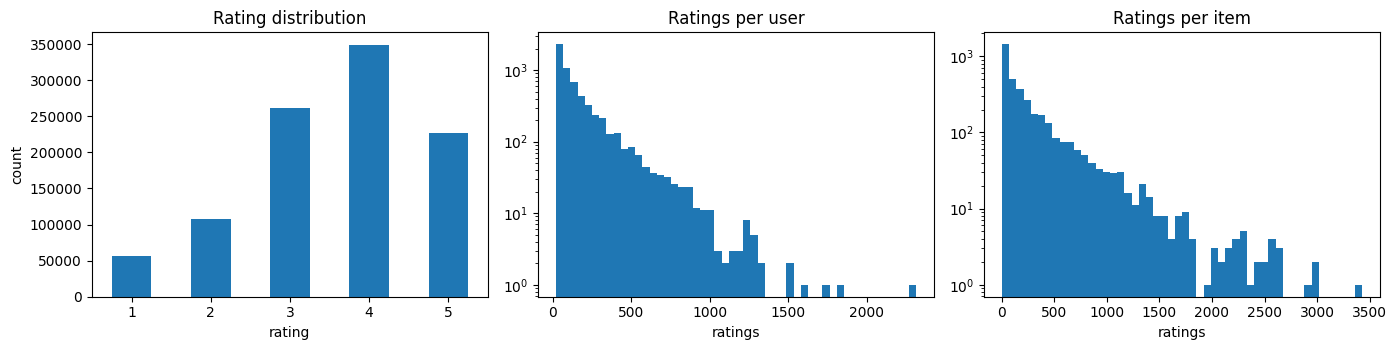

In [4]:
import numpy as np, pandas as pd, os, time, glob, random, zipfile, urllib.request
import matplotlib.pyplot as plt

WORK = "/kaggle/working" if os.path.exists("/kaggle/working") else ("/content" if os.path.exists("/content") else ".")
os.makedirs(f"{WORK}/results", exist_ok=True)
try:
    urllib.request.urlretrieve("https://files.grouplens.org/datasets/movielens/ml-1m.zip", f"{WORK}/ml-1m.zip")
    zipfile.ZipFile(f"{WORK}/ml-1m.zip").extractall(WORK)
    RATINGS = f"{WORK}/ml-1m/ratings.dat"
except Exception as e:
    print("download failed:", e)
    found = glob.glob("/kaggle/input/**/ratings.dat", recursive=True)
    print("ratings.dat found in attached inputs:", found)
    RATINGS = found[0]
print("using:", RATINGS)

df = pd.read_csv(RATINGS, sep="::", engine="python", names=["user", "item", "rating", "ts"])
assert df.shape[1] == 4 and df.rating.between(1, 5).all(), "unexpected file format"
n_users, n_items, n_r = df.user.nunique(), df.item.nunique(), len(df)
print("ratings:", n_r, "| users:", n_users, "| items:", n_items, "| density: %.4f" % (n_r / (n_users * n_items)))
print("rating distribution (share):", df.rating.value_counts(normalize=True).sort_index().round(3).to_dict(), "| mean %.3f" % df.rating.mean())
pu, pi_ = df.groupby("user").size(), df.groupby("item").size()
print("ratings per user min/median/max:", pu.min(), int(pu.median()), pu.max(), "| per item:", pi_.min(), int(pi_.median()), pi_.max())
print("items with fewer than 5 ratings: %.1f%%" % (100 * (pi_ < 5).mean()), "| duplicate (user, item) pairs:", int(df.duplicated(["user", "item"]).sum()))
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
df.rating.value_counts().sort_index().plot.bar(ax=ax[0], rot=0); ax[0].set_title("Rating distribution"); ax[0].set_xlabel("rating"); ax[0].set_ylabel("count")
ax[1].hist(pu, bins=50); ax[1].set_yscale("log"); ax[1].set_title("Ratings per user"); ax[1].set_xlabel("ratings")
ax[2].hist(pi_, bins=50); ax[2].set_yscale("log"); ax[2].set_title("Ratings per item"); ax[2].set_xlabel("ratings")
plt.tight_layout(); plt.savefig(f"{WORK}/results/cf1m_data_overview.png", dpi=150, bbox_inches="tight"); plt.show()

## Dataset: MovieLens 1M

MovieLens 1M (GroupLens; Harper and Konstan, "The MovieLens Datasets: History and
Context", ACM TiiS, 2015) holds 1,000,209 ratings from 1 to 5 by 6,040 users on
3,706 movies (density 4.47%, no duplicate pairs). Every user has at least 20 ratings
(median 96, maximum 2,314); items have 1 to 3,428 (median 123), and 7.8% of items
have fewer than 5. Ratings skew positive (mean 3.582; 4 is the most common at
34.9%). Both counts are heavy-tailed (log-scale plots).

It suits both algorithms because it has **explicit ratings**, so neighbourhood
methods and matrix factorisation can both predict a rating and be scored with RMSE
and MAE (as in the README's worked example); the matrix is **sparse but not empty**,
which is where latent factors are meant to help and where neighbourhood
similarities are noisy; and it is **large enough** for stable estimates (about
100,000 ratings each for validation and test) yet small enough for dense matrices
and a full grid in minutes. I chose 1M over 100K (used as a pilot) for tighter
comparisons. Limits: ratings are explicit, not implicit clicks (it says nothing
about CTR); only users who chose to rate appear; popularity is heavily skewed; and
it is small by industrial standards.

In [5]:
SEED = 42
rng = np.random.default_rng(SEED); random.seed(SEED)
uid = {u: k for k, u in enumerate(sorted(df.user.unique()))}; iid = {i: k for k, i in enumerate(sorted(df.item.unique()))}
d = pd.DataFrame({"u": df.user.map(uid).to_numpy(), "i": df.item.map(iid).to_numpy(), "r": df.rating.to_numpy(np.float32)})
perm = rng.permutation(len(d)); n_tr, n_va = int(0.8 * len(d)), int(0.1 * len(d))
tr, va, te = d.iloc[perm[:n_tr]], d.iloc[perm[n_tr:n_tr + n_va]], d.iloc[perm[n_tr + n_va:]]
U, I = len(uid), len(iid)
R = np.zeros((U, I), np.float32); M = np.zeros((U, I), dtype=bool)
R[tr.u, tr.i] = tr.r; M[tr.u, tr.i] = True
print("train / val / test ratings:", len(tr), len(va), len(te))
print("fingerprint | train rating sum", int(tr.r.sum()), "| val rating sum", int(va.r.sum()), "| test rating sum", int(te.r.sum()))
print("cold start in val: users unseen in train", int((~va.u.isin(tr.u)).sum()), "| items unseen in train", int((~va.i.isin(tr.i)).sum()))

def rmse(y, p): return float(np.sqrt(np.mean((y - p) ** 2)))
def mae(y, p): return float(np.mean(np.abs(y - p)))
def clip(p): return np.clip(p, 1.0, 5.0)

mu = float(tr.r.mean()); n_i = M.sum(0); n_u = M.sum(1)
item_mean = np.where(n_i > 0, R.sum(0, dtype=np.float64) / np.maximum(n_i, 1), mu).astype(np.float32)
user_mean = np.where(n_u > 0, R.sum(1, dtype=np.float64) / np.maximum(n_u, 1), mu).astype(np.float32)
LAM = 10.0
bi = ((R - mu) * M).sum(0, dtype=np.float64) / (n_i + LAM)
bu = (((R - mu - bi[None, :]) * M).sum(1, dtype=np.float64)) / (n_u + LAM)
B = (mu + bu[:, None] + bi[None, :]).astype(np.float32)
yv = va.r.to_numpy()
refs = {"global mean": np.full(len(va), mu), "item mean": item_mean[va.i.to_numpy()], "user mean": user_mean[va.u.to_numpy()],
        "bias baseline (mu+bu+bi)": B[va.u.to_numpy(), va.i.to_numpy()]}
print(pd.DataFrame([(n, rmse(yv, clip(p)), mae(yv, clip(p))) for n, p in refs.items()],
                   columns=["baseline", "val RMSE", "val MAE"]).round(4).to_string(index=False))

train / val / test ratings: 800167 100020 100022
fingerprint | train rating sum 2866305 | val rating sum 357574 | test rating sum 358434
cold start in val: users unseen in train 0 | items unseen in train 19
                baseline  val RMSE  val MAE
             global mean    1.1175   0.9329
               item mean    0.9788   0.7819
               user mean    1.0354   0.8274
bias baseline (mu+bu+bi)    0.9085   0.7191


## Split and baselines

A random 80/10/10 split of the ratings (seed 42): 800,167 train, 100,020 validation
and 100,022 test ratings; every statistic is learned from the training part only.
Mean ratings are 3.582, 3.575 and 3.584. In validation no user and 19 items (0.02%
of ratings) are unseen in training and fall back to the baseline. The bias baseline
predicts the training mean plus a user bias and an item bias, each shrunk toward
zero (sum divided by count plus 10, a choice of mine, not tuned).

| Baseline | Val RMSE | Val MAE |
|---|---|---|
| Global mean | 1.1175 | 0.9329 |
| Item mean | 0.9788 | 0.7819 |
| User mean | 1.0354 | 0.8274 |
| Bias baseline | 0.9085 | 0.7191 |

The bias baseline is the reference that matters: it is 18.7% below the global mean.

In [6]:
Rc = np.where(M, R - B, 0.0).astype(np.float32); Mf = M.astype(np.float32)
def sim_matrix(X, shrink):
    G = X @ X.T; nrm = np.sqrt(np.diag(G)); S = G / np.maximum(nrm[:, None] * nrm[None, :], 1e-12)
    if shrink > 0:
        Z = (X != 0).astype(np.float32); n_common = Z @ Z.T
        S = S * n_common / (n_common + shrink)
    np.fill_diagonal(S, 0.0); return S.astype(np.float32)
def topk_rows(S, k):
    Sk = np.zeros_like(S); idx = np.argpartition(-np.abs(S), k, axis=1)[:, :k]
    rr = np.arange(S.shape[0])[:, None]; Sk[rr, idx] = S[rr, idx]; return Sk
def predict_from_sim(S, k, kind):
    Sk = topk_rows(S, k)
    if kind == "item-item": num = Rc @ Sk.T; den = Mf @ np.abs(Sk).T
    else:                   num = Sk @ Rc;  den = np.abs(Sk) @ Mf
    return B + np.where(den > 1e-9, num / np.maximum(den, 1e-9), 0.0)

KS, SHR = (50, 100, 200, 400, 800), (0, 25, 100)
uv, iv = va.u.to_numpy(), va.i.to_numpy()
rows, pred_cache, t0 = [], {}, time.time()
for kind in ("item-item", "user-user"):
    for shrink in SHR:
        S = sim_matrix(Rc.T if kind == "item-item" else Rc, shrink)
        for k in KS:
            p = clip(predict_from_sim(S, k, kind)[uv, iv]); pred_cache[(kind, k, shrink)] = p
            rows.append((kind, k, shrink, rmse(yv, p), mae(yv, p)))
        del S
        print(kind, "shrinkage", shrink, "done | %.0f s elapsed" % (time.time() - t0))
knn = pd.DataFrame(rows, columns=["method", "k", "shrinkage", "val RMSE", "val MAE"])
print(knn.round(4).to_string(index=False)); print("grid time (s):", round(time.time() - t0))
best_knn = {}
for kind in ("item-item", "user-user"):
    sub = knn[knn.method == kind]; b = sub.loc[sub["val RMSE"].idxmin()]
    best_knn[kind] = (int(b.k), int(b.shrinkage), float(b["val RMSE"]), float(b["val MAE"]))
    print("best", kind, "k=%d shrinkage=%d | val RMSE %.4f MAE %.4f" % best_knn[kind])

def boot_diff(y, pa, pb, n=1000, seed=0):
    g = np.random.default_rng(seed); out = []
    for _ in range(n):
        s = g.integers(0, len(y), len(y)); out.append(rmse(y[s], pa[s]) - rmse(y[s], pb[s]))
    return float(np.mean(out)), float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))
p_ii = pred_cache[("item-item",) + best_knn["item-item"][:2]]; p_uu = pred_cache[("user-user",) + best_knn["user-user"][:2]]
p_b = clip(refs["bias baseline (mu+bu+bi)"])
print("RMSE(user-user) - RMSE(item-item), 95%% interval: %.4f [%.4f, %.4f]" % boot_diff(yv, p_uu, p_ii))
print("RMSE(bias baseline) - RMSE(best), 95%% interval: %.4f [%.4f, %.4f]" % boot_diff(yv, p_b, p_ii if best_knn["item-item"][2] <= best_knn["user-user"][2] else p_uu))

item-item shrinkage 0 done | 16 s elapsed
item-item shrinkage 25 done | 33 s elapsed
item-item shrinkage 100 done | 50 s elapsed
user-user shrinkage 0 done | 77 s elapsed
user-user shrinkage 25 done | 104 s elapsed
user-user shrinkage 100 done | 131 s elapsed
   method   k  shrinkage  val RMSE  val MAE
item-item  50          0    0.9123   0.7009
item-item 100          0    0.8922   0.6886
item-item 200          0    0.8745   0.6790
item-item 400          0    0.8649   0.6748
item-item 800          0    0.8624   0.6754
item-item  50         25    0.8751   0.6767
item-item 100         25    0.8637   0.6719
item-item 200         25    0.8594   0.6709
item-item 400         25    0.8596   0.6728
item-item 800         25    0.8618   0.6759
item-item  50        100    0.8688   0.6736
item-item 100        100    0.8602   0.6702
item-item 200        100    0.8577   0.6701
item-item 400        100    0.8589   0.6727
item-item 800        100    0.8615   0.6758
user-user  50          0    0.9585  

## Memory-based CF

The prediction for user u and item i is the baseline B[u,i] plus the
similarity-weighted average of the neighbours' residuals over their baselines (the
README's weighted average, applied to residuals; a residual is the baseline's
error on a known rating). Similarity is the cosine of residual vectors with
missing entries as zero, multiplied by a shrinkage n/(n + lambda) (n = co-rated
entries). Each row keeps its k most similar neighbours overall, and only neighbours
the user rated contribute; with none, the prediction falls back to the baseline.

Validation RMSE (best per column in bold in the notebook output):

| k | Item, lambda 0 | Item, 25 | Item, 100 | User, lambda 0 | User, 25 | User, 100 |
|---|---|---|---|---|---|---|
| 50 | 0.9123 | 0.8751 | 0.8688 | 0.9585 | 0.9035 | 0.8935 |
| 100 | 0.8922 | 0.8637 | 0.8602 | 0.9252 | 0.8844 | 0.8781 |
| 200 | 0.8745 | 0.8594 | **0.8577** | 0.8972 | 0.8738 | 0.8712 |
| 400 | 0.8649 | 0.8596 | 0.8589 | 0.8794 | 0.8697 | **0.8694** |
| 800 | 0.8624 | 0.8618 | 0.8615 | 0.8732 | 0.8700 | 0.8703 |

The best item-item setting (k 200, lambda 100) reaches RMSE 0.8577 and MAE 0.6701,
against 0.9085 and 0.7191 for the bias baseline (5.6% and 6.8% better). 27 of the
30 settings beat the baseline. Item-item beat user-user in all 15 matched settings;
the paired bootstrap of RMSE(user-user) - RMSE(item-item) is 0.0117 with 95%
interval [0.0104, 0.0130], so the gap is not sampling noise on these validation
ratings (it does not cover split-to-split variation or the optimism from choosing
the best of 30 settings on the same ratings). The best shrinkage was the largest
tried for both methods, so it is extended in the next step.

In [7]:
rows = []; t0 = time.time()
for kind in ("item-item", "user-user"):
    for shrink in (200, 400):
        S = sim_matrix(Rc.T if kind == "item-item" else Rc, shrink)
        for k in (200, 400):
            p = clip(predict_from_sim(S, k, kind)[uv, iv]); pred_cache[(kind, k, shrink)] = p
            rows.append((kind, k, shrink, rmse(yv, p), mae(yv, p)))
        del S
ext = pd.DataFrame(rows, columns=["method", "k", "shrinkage", "val RMSE", "val MAE"])
print(ext.round(4).to_string(index=False)); print("extension time (s):", round(time.time() - t0))
knn_all = pd.concat([knn, ext], ignore_index=True)
best_knn = {}
for kind in ("item-item", "user-user"):
    sub = knn_all[knn_all.method == kind]; b = sub.loc[sub["val RMSE"].idxmin()]
    best_knn[kind] = (int(b.k), int(b.shrinkage), float(b["val RMSE"]), float(b["val MAE"]))
    print("best", kind, "k=%d shrinkage=%d | val RMSE %.4f MAE %.4f" % best_knn[kind])
p_ii = pred_cache[("item-item",) + best_knn["item-item"][:2]]; p_uu = pred_cache[("user-user",) + best_knn["user-user"][:2]]
print("RMSE(user-user) - RMSE(item-item), 95%% interval: %.4f [%.4f, %.4f]" % boot_diff(yv, p_uu, p_ii))

   method   k  shrinkage  val RMSE  val MAE
item-item 200        200    0.8575   0.6702
item-item 400        200    0.8588   0.6728
item-item 200        400    0.8575   0.6703
item-item 400        400    0.8586   0.6728
user-user 200        200    0.8710   0.6823
user-user 400        200    0.8695   0.6821
user-user 200        400    0.8709   0.6824
user-user 400        400    0.8697   0.6824
extension time (s): 39
best item-item k=200 shrinkage=400 | val RMSE 0.8575 MAE 0.6703
best user-user k=400 shrinkage=100 | val RMSE 0.8694 MAE 0.6819
RMSE(user-user) - RMSE(item-item), 95% interval: 0.0119 [0.0106, 0.0132]


## Wider shrinkage

Shrinkage 200 and 400 at k = 200 and 400: item-item gives 0.8575 at k = 200 for
both (against 0.8577 at shrinkage 100), so the curve is flat beyond about 100 and
the grid edge does not matter. The selected item-item setting is k = 200,
shrinkage 400 (RMSE 0.8575, MAE 0.6703), effectively tied with shrinkage 100 to
400. The best user-user setting stays at k = 400, shrinkage 100 (0.8694 / 0.6819).
Paired bootstrap of RMSE(user-user) - RMSE(item-item): 0.0119, 95% interval
[0.0106, 0.0132].

In [8]:
def fit_mf(f, reg, lr=0.01, epochs=100, bs=256, seed=SEED, patience=5):
    g = np.random.default_rng(seed)
    bu_, bi_ = np.zeros(U, np.float32), np.zeros(I, np.float32)
    P = g.normal(0, 0.1, (U, f)).astype(np.float32); Q = g.normal(0, 0.1, (I, f)).astype(np.float32)
    u_tr, i_tr, r_tr = tr.u.to_numpy(), tr.i.to_numpy(), tr.r.to_numpy()
    def predict(u, i): return mu + bu_[u] + bi_[i] + (P[u] * Q[i]).sum(1)
    hist, best, bad = [], (np.inf, None, 0), 0
    sub = np.random.default_rng(0).choice(len(r_tr), 100000, replace=False)       # fixed subset for the train-RMSE curve
    for ep in range(1, epochs + 1):
        order = g.permutation(len(r_tr))
        for s in range(0, len(order), bs):
            idx = order[s:s + bs]; u, i, r = u_tr[idx], i_tr[idx], r_tr[idx]
            e = r - predict(u, i)                                   # prediction error
            Pu, Qi = P[u].copy(), Q[i].copy()                       # values before the update
            np.add.at(bu_, u, lr * (e - reg * bu_[u])); np.add.at(bi_, i, lr * (e - reg * bi_[i]))
            np.add.at(P, u, lr * (e[:, None] * Qi - reg * Pu)); np.add.at(Q, i, lr * (e[:, None] * Pu - reg * Qi))
        tr_r = rmse(r_tr[sub], clip(predict(u_tr[sub], i_tr[sub]))); va_r = rmse(yv, clip(predict(uv, iv)))
        hist.append((ep, tr_r, va_r))
        if va_r < best[0] - 1e-5:
            best = (va_r, (bu_.copy(), bi_.copy(), P.copy(), Q.copy()), ep); bad = 0
        else:
            bad += 1
            if bad >= patience: break
    return best, hist

GRID = [(f, reg) for f in (16, 32, 64) for reg in (0.02, 0.05, 0.1)]
EPOCHS = 100
mf_res, rows, t0 = {}, [], time.time()
for f, reg in GRID:
    t1 = time.time(); best_, hist_ = fit_mf(f, reg, epochs=EPOCHS)
    bu_m, bi_m, P_m, Q_m = best_[1]
    pv = clip(mu + bu_m[uv] + bi_m[iv] + (P_m[uv] * Q_m[iv]).sum(1))
    mf_res[(f, reg)] = (best_, hist_)
    rows.append((f, reg, best_[2], len(hist_), rmse(yv, pv), mae(yv, pv), time.time() - t1))
    print("factors", f, "reg", reg, "| best epoch", best_[2], "| val RMSE %.4f | %.0f s" % (rmse(yv, pv), time.time() - t1))
mf_tab = pd.DataFrame(rows, columns=["factors", "reg", "best epoch", "epochs run", "val RMSE", "val MAE", "sec"])
print(mf_tab.round(4).to_string(index=False)); print("grid time (s):", round(time.time() - t0))
bm = mf_tab.loc[mf_tab["val RMSE"].idxmin()]; mf_cfg = (int(bm.factors), float(bm.reg))
print("selected MF by val RMSE: factors", mf_cfg[0], "reg", mf_cfg[1], "| val RMSE %.4f MAE %.4f | best epoch %d of at most %d" % (bm["val RMSE"], bm["val MAE"], bm["best epoch"], EPOCHS))

factors 16 reg 0.02 | best epoch 18 | val RMSE 0.8630 | 21 s
factors 16 reg 0.05 | best epoch 35 | val RMSE 0.8533 | 36 s
factors 16 reg 0.1 | best epoch 99 | val RMSE 0.8634 | 88 s
factors 32 reg 0.02 | best epoch 12 | val RMSE 0.8664 | 23 s
factors 32 reg 0.05 | best epoch 26 | val RMSE 0.8525 | 42 s
factors 32 reg 0.1 | best epoch 76 | val RMSE 0.8631 | 110 s
factors 64 reg 0.02 | best epoch 11 | val RMSE 0.8690 | 37 s
factors 64 reg 0.05 | best epoch 25 | val RMSE 0.8520 | 70 s
factors 64 reg 0.1 | best epoch 81 | val RMSE 0.8621 | 202 s
 factors  reg  best epoch  epochs run  val RMSE  val MAE      sec
      16 0.02          18          23    0.8630   0.6744  21.3145
      16 0.05          35          40    0.8533   0.6693  35.5462
      16 0.10          99         100    0.8634   0.6823  88.1608
      32 0.02          12          17    0.8664   0.6796  22.7469
      32 0.05          26          31    0.8525   0.6693  42.3594
      32 0.10          76          81    0.8631   0.6822

## Matrix factorisation (from scratch)

Prediction r̂ = μ + b_u + b_i + p_u · q_i, with user and item vectors of length
`f`. Loss: squared error plus an L2 penalty (strength `reg`) on the biases and
vectors. Optimisation: mini-batch SGD with hand-written gradients (batch 256,
learning rate 0.01): with e = r - r̂, b_u += lr(e - reg b_u), b_i likewise, p_u +=
lr(e q_i - reg p_u), q_i += lr(e p_u - reg q_i), using the values from before the
step. Factors start at N(0, 0.1²), biases at 0. Early stopping on validation RMSE
(patience 5, at most 100 epochs); predictions clipped to [1, 5]; seed 42.

Validation RMSE (best epoch in brackets):

| Factors | reg 0.02 | reg 0.05 | reg 0.1 |
|---|---|---|---|
| 16 | 0.8630 (18) | 0.8533 (35) | 0.8634 (99, at the cap) |
| 32 | 0.8664 (12) | 0.8525 (26) | 0.8631 (76) |
| 64 | 0.8690 (11) | **0.8520** (25) | 0.8621 (81) |

Regularisation 0.05 is best at every size. With 0.02 the models overfit: they peak
early and more factors make the result worse. More factors help by under 0.0013 at
reg 0.05, probably within seed noise. The 16-factor reg 0.1 run stopped at the
epoch cap while still improving. Selected: 64 factors, reg 0.05 (RMSE 0.8520, MAE
0.6693). The grid took 629 s.

RMSE(bias baseline) - RMSE(MF), 95% interval: 0.0564 [0.0544, 0.0585]
RMSE(best item-item) - RMSE(MF), 95% interval: 0.0055 [0.0039, 0.0072]


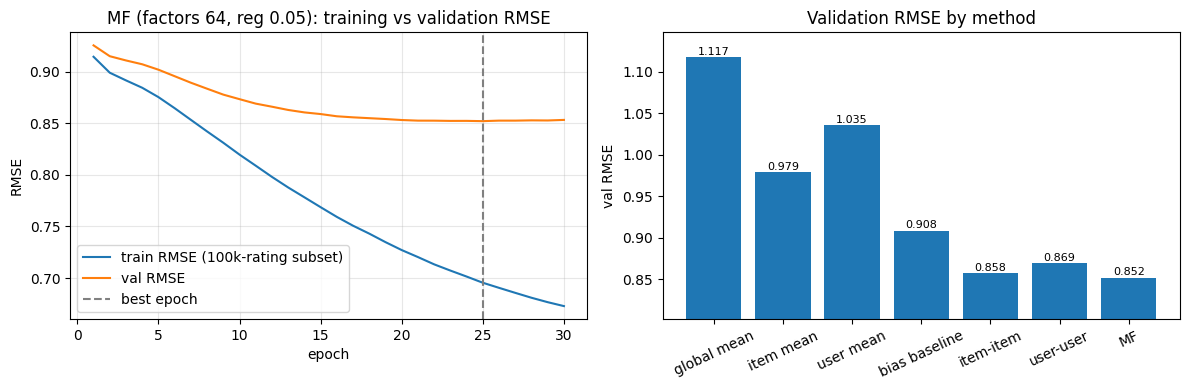

In [9]:
best_, hist_ = mf_res[mf_cfg]; h = np.array(hist_)
bu_m, bi_m, P_m, Q_m = best_[1]
p_mf = clip(mu + bu_m[uv] + bi_m[iv] + (P_m[uv] * Q_m[iv]).sum(1))
best_kind = min(best_knn, key=lambda k_: best_knn[k_][2]); p_best_knn = p_ii if best_kind == "item-item" else p_uu
print("RMSE(bias baseline) - RMSE(MF), 95%% interval: %.4f [%.4f, %.4f]" % boot_diff(yv, p_b, p_mf))
print("RMSE(best %s) - RMSE(MF), 95%% interval: %.4f [%.4f, %.4f]" % ((best_kind,) + boot_diff(yv, p_best_knn, p_mf)))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h[:, 0], h[:, 1], label="train RMSE (100k-rating subset)"); ax[0].plot(h[:, 0], h[:, 2], label="val RMSE")
ax[0].axvline(best_[2], color="gray", linestyle="--", label="best epoch"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("RMSE")
ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_title("MF (factors %d, reg %.2f): training vs validation RMSE" % mf_cfg)
names = ["global mean", "item mean", "user mean", "bias baseline", "item-item", "user-user", "MF"]
vals = [rmse(yv, clip(refs[n])) for n in ("global mean", "item mean", "user mean", "bias baseline (mu+bu+bi)")] + [
        best_knn["item-item"][2], best_knn["user-user"][2], float(bm["val RMSE"])]
ax[1].bar(names, vals); ax[1].set_ylim(min(vals) - 0.05, max(vals) + 0.03); ax[1].set_ylabel("val RMSE")
for i_, v_ in enumerate(vals): ax[1].text(i_, v_ + 0.003, "%.3f" % v_, ha="center", fontsize=8)
ax[1].tick_params(axis="x", rotation=25); ax[1].set_title("Validation RMSE by method")
plt.tight_layout(); plt.savefig(f"{WORK}/results/cf1m_mf_and_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

## Comparison on validation

| Method | Val RMSE | Val MAE |
|---|---|---|
| Global mean | 1.1175 | 0.9329 |
| Item mean | 0.9788 | 0.7819 |
| User mean | 1.0354 | 0.8274 |
| Bias baseline | 0.9085 | 0.7191 |
| User-user (k 400, shrinkage 100) | 0.8694 | 0.6819 |
| Item-item (k 200, shrinkage 400) | 0.8575 | 0.6703 |
| Matrix factorisation (64, reg 0.05) | **0.8520** | **0.6693** |

Paired bootstrap, RMSE(item-item) - RMSE(MF): 0.0055 [0.0039, 0.0072]; RMSE(bias
baseline) - RMSE(MF): 0.0564 [0.0544, 0.0585]. MF is better than item-item beyond
sampling noise on the validation ratings, but the margin is small (0.6%), and the
MAE difference is only 0.001. The training curve shows overfitting: train RMSE
keeps falling (to about 0.67) while validation RMSE flattens near 0.853 by epoch
20; early stopping selected epoch 25. The best of 9 MF configurations and 50
neighbourhood settings was chosen on the same validation ratings, so the margins
are slightly optimistic; test is run once at the end.

In [10]:
sel_f, sel_reg = mf_cfg
seed_rows = [(SEED, float(bm["val RMSE"]))]
for s_ in (43, 44):
    b_, h_ = fit_mf(sel_f, sel_reg, epochs=EPOCHS, seed=s_)
    bu2, bi2, P2, Q2 = b_[1]
    pv = clip(mu + bu2[uv] + bi2[iv] + (P2[uv] * Q2[iv]).sum(1)); seed_rows.append((s_, rmse(yv, pv)))
    print("seed", s_, "| best epoch", b_[2], "| val RMSE %.4f" % rmse(yv, pv))
sv = np.array([r[1] for r in seed_rows])
print("selected MF (factors %d, reg %.2f) over seeds 42, 43, 44: mean %.4f | std %.4f | values %s" % (sel_f, sel_reg, sv.mean(), sv.std(), np.round(sv, 4).tolist()))

seed 43 | best epoch 23 | val RMSE 0.8536
seed 44 | best epoch 22 | val RMSE 0.8538
selected MF (factors 64, reg 0.05) over seeds 42, 43, 44: mean 0.8532 | std 0.0008 | values [0.852, 0.8536, 0.8538]


## Seed check for the selected MF

64 factors, reg 0.05, seeds 42, 43, 44: validation RMSE 0.8520, 0.8536, 0.8538
(mean 0.8532, standard deviation 0.0008, which is rough with three seeds). All are
below item-item's 0.8575, so the advantage over item-item survives seed noise
(0.0043 on the mean). The final model is the seed-42 run, the best of the three, so
its validation RMSE is slightly optimistic.

In [11]:
def rank_eval(Score, exclude, Rel, K=10):
    S = np.where(exclude, -np.inf, Score)
    top = np.argpartition(-S, K, axis=1)[:, :K]
    top = np.take_along_axis(top, np.argsort(-np.take_along_axis(S, top, 1), axis=1), 1)
    hits = np.take_along_axis(Rel, top, 1).astype(np.float64)
    n_rel = Rel.sum(1); users = n_rel > 0
    disc = 1.0 / np.log2(np.arange(2, K + 2)); cum = np.cumsum(disc)
    dcg = (hits * disc).sum(1); idcg = np.where(users, cum[np.maximum(np.minimum(n_rel, K) - 1, 0)], 1.0)
    prec = hits.sum(1) / K; rec = np.where(users, hits.sum(1) / np.maximum(n_rel, 1), 0.0); ndcg = dcg / idcg
    return float(prec[users].mean()), float(rec[users].mean()), float(ndcg[users].mean()), int(users.sum())

def within_user_ndcg(d_eval, pred, K=10):
    d = pd.DataFrame({"u": d_eval.u.to_numpy(), "r": d_eval.r.to_numpy(), "p": pred})
    disc = 1.0 / np.log2(np.arange(2, K + 2)); out = []
    for _, g in d.groupby("u"):
        if len(g) < 2: continue
        r_by_p = g.sort_values("p", ascending=False, kind="stable").r.to_numpy()[:K]
        r_ideal = np.sort(g.r.to_numpy())[::-1][:K]
        out.append((r_by_p * disc[:len(r_by_p)]).sum() / (r_ideal * disc[:len(r_ideal)]).sum())
    return float(np.mean(out))

def full_scores():
    sc = {}; g = np.random.default_rng(SEED)
    sc["random"] = g.random((U, I)).astype(np.float32)
    sc["popularity"] = np.tile(n_i.astype(np.float32) + 1e-3 * g.random(I).astype(np.float32), (U, 1))
    sc["bias baseline"] = B
    k_, s_ = best_knn["item-item"][:2]; sc["item-item"] = predict_from_sim(sim_matrix(Rc.T, s_), k_, "item-item")
    k_, s_ = best_knn["user-user"][:2]; sc["user-user"] = predict_from_sim(sim_matrix(Rc, s_), k_, "user-user")
    sc["MF"] = (mu + bu_m[:, None] + bi_m[None, :] + P_m @ Q_m.T).astype(np.float32)
    return sc
t0 = time.time(); scores = full_scores(); print("score matrices built in %.0f s" % (time.time() - t0))
pos = va[va.r >= 4]; Rel_va = np.zeros((U, I), bool); Rel_va[pos.u, pos.i] = True
rows = [(n,) + rank_eval(Sc, M, Rel_va) for n, Sc in scores.items()]
rk_val = pd.DataFrame(rows, columns=["method", "precision@10", "recall@10", "NDCG@10", "users evaluated"])
print("validation top-10 ranking (relevant = val rating >= 4; all unseen movies ranked):"); print(rk_val.round(4).to_string(index=False))
pv_all = {"global mean": np.full(len(va), mu), "item mean": item_mean[iv], "user mean": user_mean[uv],
          "bias baseline": B[uv, iv], "item-item": scores["item-item"][uv, iv], "user-user": scores["user-user"][uv, iv],
          "MF": scores["MF"][uv, iv]}
print("within-user NDCG@10 on each user's own held-out validation items (gain = rating; global mean and user mean = chance level):")
print(pd.Series({n: within_user_ndcg(va, p) for n, p in pv_all.items()}).round(4).to_string())

score matrices built in 12 s
validation top-10 ranking (relevant = val rating >= 4; all unseen movies ranked):
       method  precision@10  recall@10  NDCG@10  users evaluated
       random        0.0031     0.0033   0.0036             5722
   popularity        0.0768     0.0863   0.1033             5722
bias baseline        0.0321     0.0364   0.0426             5722
    item-item        0.0244     0.0174   0.0260             5722
    user-user        0.0001     0.0002   0.0002             5722
           MF        0.0392     0.0439   0.0505             5722
within-user NDCG@10 on each user's own held-out validation items (gain = rating; global mean and user mean = chance level):
global mean      0.8691
item mean        0.9323
user mean        0.8691
bias baseline    0.9325
item-item        0.9453
user-user        0.9419
MF               0.9452


## Ranking metrics (validation)

For each user all movies unrated in training are ranked by predicted rating
(unclipped) and the top 10 compared with validation ratings of 4 or more (5,722
users have at least one). Unrated movies count as misses even if the user would
have liked them, so absolute values are low.

| Method | Precision@10 | Recall@10 | NDCG@10 |
|---|---|---|---|
| Random | 0.0031 | 0.0033 | 0.0036 |
| Popularity (training counts) | 0.0768 | 0.0863 | 0.1033 |
| Bias baseline | 0.0321 | 0.0364 | 0.0426 |
| Item-item | 0.0244 | 0.0174 | 0.0260 |
| User-user | 0.0001 | 0.0002 | 0.0002 |
| MF | 0.0392 | 0.0439 | 0.0505 |

Popularity beats every rating-based method; MF is the best of those. User-user's
top-10 is almost empty of hits. A possible reason (untested) is that a movie rated
by a single neighbour receives that neighbour's whole residual, producing extreme
predictions for obscure movies that rarely appear in held-out data; a damped
denominator would be the standard remedy. This is a limitation of my
ranking-by-predicted-rating setup, not evidence that predicted ratings are poor.

Within-user NDCG@10 ranks only each user's own held-out movies by predicted rating
and scores the order against the true ratings (gain = rating):

| Method | Validation |
|---|---|
| Global mean, user mean (chance level) | 0.8691 |
| Item mean | 0.9323 |
| Bias baseline | 0.9325 |
| User-user | 0.9419 |
| Item-item | 0.9453 |
| MF | 0.9452 |

Item-item and MF tie (no intervals computed). The bias baseline equals the item
mean because a user bias shifts all of a user's predictions equally and cannot
change their order.

In [12]:
te_u, te_i, yt = te.u.to_numpy(), te.i.to_numpy(), te.r.to_numpy()
Mva = np.zeros((U, I), bool); Mva[va.u, va.i] = True
pt = {"global mean": np.full(len(te), mu), "item mean": item_mean[te_i], "user mean": user_mean[te_u],
      "bias baseline": B[te_u, te_i], "item-item": scores["item-item"][te_u, te_i], "user-user": scores["user-user"][te_u, te_i],
      "MF": mu + bu_m[te_u] + bi_m[te_i] + (P_m[te_u] * Q_m[te_i]).sum(1)}
def boot_ci(y, p, n=1000, seed=0):
    g = np.random.default_rng(seed); out = []
    for _ in range(n):
        s = g.integers(0, len(y), len(y)); out.append(rmse(y[s], clip(p[s])))
    return float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))
rows = []
for n, p in pt.items():
    lo, hi = boot_ci(yt, p); rows.append((n, rmse(yt, clip(p)), lo, hi, mae(yt, clip(p))))
test_tab = pd.DataFrame(rows, columns=["method", "test RMSE", "CI low", "CI high", "test MAE"])
print("TEST (one run; models trained on the train split only):"); print(test_tab.round(4).to_string(index=False))
pos = te[te.r >= 4]; Rel_te = np.zeros((U, I), bool); Rel_te[pos.u, pos.i] = True
rows = [(n,) + rank_eval(Sc, M | Mva, Rel_te) for n, Sc in scores.items()]
rk_te = pd.DataFrame(rows, columns=["method", "precision@10", "recall@10", "NDCG@10", "users evaluated"])
print("test top-10 ranking (relevant = test rating >= 4; train and val movies excluded):"); print(rk_te.round(4).to_string(index=False))
print("within-user NDCG@10 on each user's own held-out TEST items:")
print(pd.Series({n: within_user_ndcg(te, p) for n, p in pt.items()}).round(4).to_string())
print("RMSE(item-item) - RMSE(MF) on test, 95%% interval: %.4f [%.4f, %.4f]" % boot_diff(yt, clip(pt["item-item"]), clip(pt["MF"])))

TEST (one run; models trained on the train split only):
       method  test RMSE  CI low  CI high  test MAE
  global mean     1.1160  1.1114   1.1206    0.9327
    item mean     0.9742  0.9699   0.9786    0.7782
    user mean     1.0334  1.0287   1.0379    0.8273
bias baseline     0.9031  0.8989   0.9073    0.7153
    item-item     0.8523  0.8481   0.8563    0.6679
    user-user     0.8643  0.8601   0.8684    0.6792
           MF     0.8471  0.8431   0.8512    0.6668
test top-10 ranking (relevant = test rating >= 4; train and val movies excluded):
       method  precision@10  recall@10  NDCG@10  users evaluated
       random        0.0030     0.0033   0.0035             5749
   popularity        0.0894     0.0944   0.1201             5749
bias baseline        0.0340     0.0371   0.0450             5749
    item-item        0.0271     0.0178   0.0283             5749
    user-user        0.0001     0.0003   0.0002             5749
           MF        0.0414     0.0453   0.0528         

## Test (one run; all models trained on the train split only)

| Method | Test RMSE (95% CI) | Test MAE |
|---|---|---|
| Global mean | 1.1160 [1.1114, 1.1206] | 0.9327 |
| Item mean | 0.9742 [0.9699, 0.9786] | 0.7782 |
| User mean | 1.0334 [1.0287, 1.0379] | 0.8273 |
| Bias baseline | 0.9031 [0.8989, 0.9073] | 0.7153 |
| User-user (k 400, shrinkage 100) | 0.8643 [0.8601, 0.8684] | 0.6792 |
| Item-item (k 200, shrinkage 400) | 0.8523 [0.8481, 0.8563] | 0.6679 |
| MF (64 factors, reg 0.05) | **0.8471 [0.8431, 0.8512]** | **0.6668** |

The ordering from validation holds, and every method is about 0.005 lower on test
(a slightly easier split for all of them). RMSE(item-item) - RMSE(MF) is 0.0052
with a 95% interval of [0.0036, 0.0068]. The MAE gap between item-item and MF is
only 0.0011. Top-10 on test: popularity precision 0.0894 (NDCG 0.1201), MF 0.0414
(0.0528), bias baseline 0.0340, item-item 0.0271, random 0.0030, user-user 0.0001;
within-user NDCG@10 on test: item-item 0.9443, MF 0.9445, user-user 0.9419, bias
baseline 0.9332, chance 0.8686.